In [1]:
import pandas as pd
import numpy as np

In [2]:
path = r"C:\Users\UI450907\Desktop\TE RWEST\Tesis\Results _IEEE39\Small Signal\Small Signal.xlsx"

dfs = pd.read_excel(path,sheet_name = None)


In [7]:
import pandas as pd

data = {
    "Case": [
        "R00","R01","R02","R03","R04","R05","R06",
        "R06A","R06B","R06BA",
        "R07","R07A","R07B",
        "R08","R08A",
        "R09-Slack","R09A-Slack"
    ],

    "Mode": [
        "Mode 00005","Mode 00019","Mode 00021","Mode 00023","Mode 00031","Mode 00029","Mode 00031",
        "Mode 00032","Mode 00035","Mode 00035",
        "Mode 00001","Mode 00034","Mode 00037",
        "Mode 00001","Mode 00042",
        "Mode 00043","Mode 00044"
    ],

    "sigma_real": [
        -0.197,-0.388,-0.388,-0.387,-0.467,-0.391,-0.413,
        -0.532,-0.590,-0.570,
        81.87,-0.551,-0.613,
        152.62,-0.569,
        -0.4767,-0.4218
    ],

    "omega_imag": [
        6.975,6.620,6.752,6.754,7.541,6.257,6.545,
        7.237,6.046,6.013,
        0.0,6.775,6.0426,
        0.0,6.811,
        3.9808,3.8147
    ],

    "frequency_Hz": [
        1.110,1.053,1.074,1.074,1.200,0.996,1.041,
        1.151,0.960,0.957,
        None,1.078,0.962,
        None,1.080,
        0.6174,0.607
    ],

    "damping_pct": [
        2.82,5.85,5.733,5.727,6.183,6.241,6.306,
        7.33,9.721,9.44,
        None,8.109,10.089,
        None,8.336,
        12.094,10.991
    ],

    "damping_time_const_s": [
        5.074,2.58,2.578,2.581,2.14,2.555,2.41,
        1.879,1.693,1.753,
        None,1.814,1.631,
        None,1.755,
        2.115,2.370
    ]
}

df = pd.DataFrame(data)

print(df)

          Case        Mode  sigma_real  omega_imag  frequency_Hz  damping_pct  \
0          R00  Mode 00005     -0.1970      6.9750        1.1100        2.820   
1          R01  Mode 00019     -0.3880      6.6200        1.0530        5.850   
2          R02  Mode 00021     -0.3880      6.7520        1.0740        5.733   
3          R03  Mode 00023     -0.3870      6.7540        1.0740        5.727   
4          R04  Mode 00031     -0.4670      7.5410        1.2000        6.183   
5          R05  Mode 00029     -0.3910      6.2570        0.9960        6.241   
6          R06  Mode 00031     -0.4130      6.5450        1.0410        6.306   
7         R06A  Mode 00032     -0.5320      7.2370        1.1510        7.330   
8         R06B  Mode 00035     -0.5900      6.0460        0.9600        9.721   
9        R06BA  Mode 00035     -0.5700      6.0130        0.9570        9.440   
10         R07  Mode 00001     81.8700      0.0000           NaN          NaN   
11        R07A  Mode 00034  

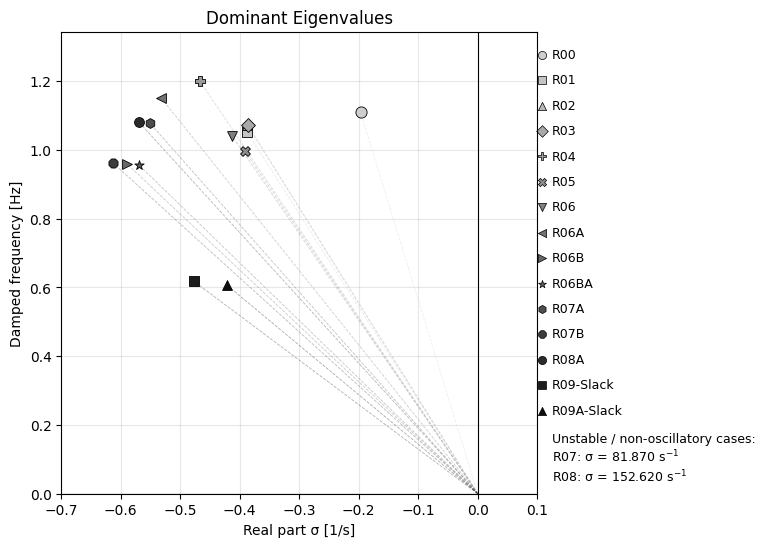

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle

# ----------------------------
# Build dataframe
# ----------------------------
df = pd.DataFrame(data)

# ----------------------------
# Numeric conversion (safe)
# ----------------------------
for col in ["sigma_real", "omega_imag", "frequency_Hz", "damping_pct", "damping_time_const_s"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ----------------------------
# Split stable / unstable cases
# Stable oscillatory modes: frequency available
# Unstable or non-oscillatory: frequency missing
# ----------------------------
stable_df = df[df["frequency_Hz"].notna()].copy()
unstable_df = df[df["frequency_Hz"].isna()].copy()

# ----------------------------
# Dynamic axis limits based on stable points
# but forcing the origin to be visible
# ----------------------------
if not stable_df.empty:
    x_min = stable_df["sigma_real"].min()
    y_max = stable_df["frequency_Hz"].max()

    x_margin = max(0.05, 0.12 * abs(x_min))
    y_margin = max(0.05, 0.12 * y_max)

    xlim = (min(-0.7, x_min - x_margin), 0.1)
    ylim = (0, y_max + y_margin)
else:
    xlim = (-0.7, 0.1)
    ylim = (0, 1.5)

# ----------------------------
# Style settings
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 6))

ax.axvline(0, color="black", linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.8)

# grayscale colors with dynamic length
colors = plt.cm.Greys(np.linspace(0.3, 0.95, max(len(stable_df), 2)))

# dynamic marker cycle
marker_cycle = cycle(['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>', '*', 'h', '8'])

legend_entries = []

# ----------------------------
# Plot stable oscillatory modes
# ----------------------------
for i, (_, row) in enumerate(stable_df.iterrows()):
    x = row["sigma_real"]
    y = row["frequency_Hz"]
    case = row["Case"]

    c = colors[i % len(colors)]
    marker = next(marker_cycle)

    # slightly larger size for low-damped modes
    if pd.notna(row.get("damping_pct", np.nan)) and row["damping_pct"] < 5:
        size = 65
    else:
        size = 50

    # eigenvalue marker
    ax.scatter(
        x, y,
        s=size,
        facecolor=c,
        edgecolor="black",
        marker=marker,
        linewidths=0.6,
        zorder=3
    )

    # dashed ray from origin to eigenvalue
    r = np.sqrt(x**2 + y**2)
    if r > 0:
        ax.plot(
            [0, x],
            [0, y],
            linestyle="--",
            linewidth=0.6,
            color=c,
            alpha=0.35,
            zorder=2
        )

    # dynamic legend label
    if "PV_penetration_pct" in df.columns and pd.notna(row.get("PV_penetration_pct", np.nan)):
        label = f"{case} ({row['PV_penetration_pct']:.1f}% PV)"
    else:
        label = case

    legend_entries.append((label, marker, c))

# ----------------------------
# Annotate unstable / non-oscillatory cases dynamically
# ----------------------------
unstable_notes = []
for _, row in unstable_df.iterrows():
    case = row["Case"]
    sigma = row["sigma_real"]

    if pd.notna(sigma):
        unstable_notes.append(f"{case}: σ = {sigma:.3f} s$^{{-1}}$")
    else:
        unstable_notes.append(f"{case}: unstable / no oscillatory mode")

# ----------------------------
# Axes formatting
# ----------------------------
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("Real part σ [1/s]")
ax.set_ylabel("Damped frequency [Hz]")
ax.set_title("Dominant Eigenvalues")
ax.grid(True, alpha=0.3)

# leave room for custom legend text
plt.subplots_adjust(right=0.72)

# ----------------------------
# Custom legend outside axis
# ----------------------------
x_text = 1.03
y0 = 0.95
dy = 0.055

for k, (label, marker, c) in enumerate(legend_entries):
    y_pos = y0 - k * dy

    ax.scatter(
        x_text - 0.02,
        y_pos,
        marker=marker,
        s=35,
        color=c,
        edgecolor="black",
        linewidths=0.5,
        transform=ax.transAxes,
        clip_on=False
    )

    ax.text(
        x_text,
        y_pos,
        label,
        transform=ax.transAxes,
        fontsize=9,
        va="center"
    )

# ----------------------------
# Unstable cases note
# ----------------------------
if unstable_notes:
    note_text = "Unstable / non-oscillatory cases:\n" + "\n".join(unstable_notes)
    ax.text(
        1.03,
        0.02,
        note_text,
        transform=ax.transAxes,
        fontsize=9,
        va="bottom"
    )

plt.show()

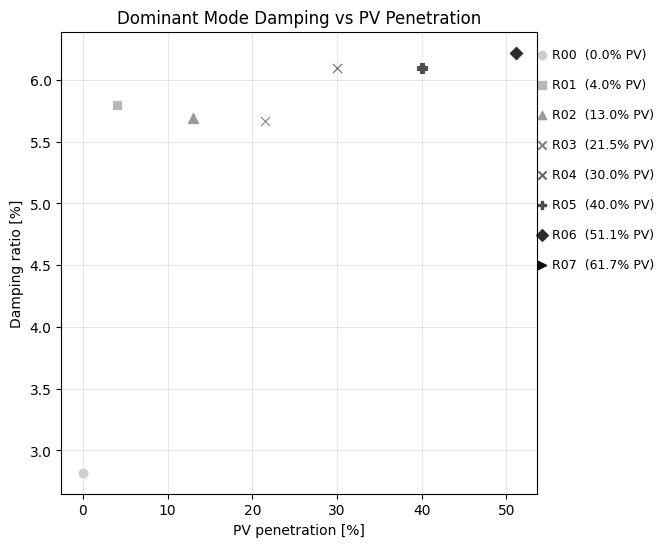

In [5]:
plt.figure(figsize=(8,6))

ax = plt.gca()

colors = plt.cm.Greys(np.linspace(0.3, 0.95, len(df)))
markers = ['o','s','^','x','x','P','D','>']
sizes = [40,40,55,40,45,45,40,40]

legend_entries = []

for i, (_, row) in enumerate(df.iterrows()):

    x = row["PV_penetration_pct"]
    y = row["damping_pct"]

    if y is None:
        continue

    case = row["Case"]
    pv = row["PV_penetration_pct"]

    c = colors[i]
    marker = markers[i % len(markers)]
    size = sizes[i % len(sizes)]

    plt.scatter(
        x,
        y,
        s=size,
        facecolor=c,
        marker=marker,
        linewidths=0.8,
        zorder=3
    )

    legend_entries.append((case, pv, marker, c))

plt.xlabel("PV penetration [%]")
plt.ylabel("Damping ratio [%]")
plt.title("Dominant Mode Damping vs PV Penetration")

plt.grid(True, alpha=0.3)

plt.subplots_adjust(right=0.72)

x_text = 1.03
y0 = 0.95
dy = 0.065

for k, (case, pv, marker, c) in enumerate(legend_entries):

    y_pos = y0 - k*dy

    ax.scatter(
        x_text - 0.02,
        y_pos,
        marker=marker,
        s=35,
        color=c,
        transform=ax.transAxes,
        clip_on=False
    )

    ax.text(
        x_text,
        y_pos,
        f"{case}  ({pv:.1f}% PV)",
        transform=ax.transAxes,
        fontsize=9,
        va="center"
    )

plt.show()

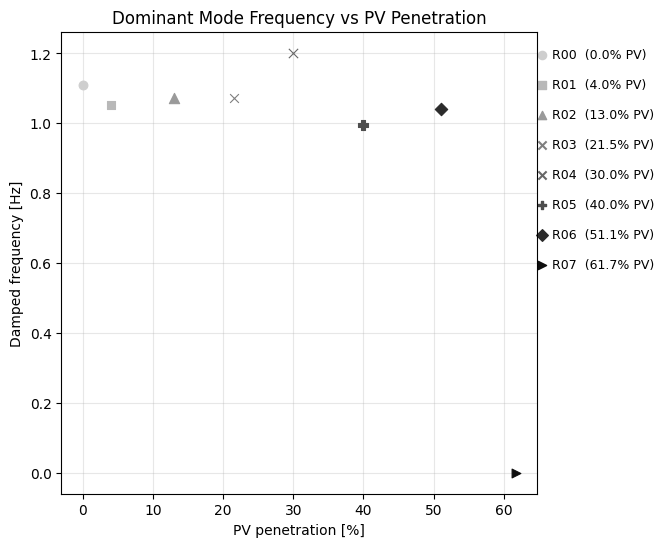

In [6]:
plt.figure(figsize=(8,6))

ax = plt.gca()

colors = plt.cm.Greys(np.linspace(0.3, 0.95, len(df)))
markers = ['o','s','^','x','x','P','D','>']
sizes = [40,40,55,40,45,45,40,40]

legend_entries = []

for i, (_, row) in enumerate(df.iterrows()):

    x = row["PV_penetration_pct"]
    y = row["frequency_Hz"]

    case = row["Case"]
    pv = row["PV_penetration_pct"]

    c = colors[i]
    marker = markers[i % len(markers)]
    size = sizes[i % len(sizes)]

    plt.scatter(
        x,
        y,
        s=size,
        facecolor=c,
        marker=marker,
        linewidths=0.8,
        zorder=3
    )

    legend_entries.append((case, pv, marker, c))

plt.xlabel("PV penetration [%]")
plt.ylabel("Damped frequency [Hz]")
plt.title("Dominant Mode Frequency vs PV Penetration")

plt.grid(True, alpha=0.3)

plt.subplots_adjust(right=0.72)

x_text = 1.03
y0 = 0.95
dy = 0.065

for k, (case, pv, marker, c) in enumerate(legend_entries):

    y_pos = y0 - k*dy

    ax.scatter(
        x_text - 0.02,
        y_pos,
        marker=marker,
        s=35,
        color=c,
        transform=ax.transAxes,
        clip_on=False
    )

    ax.text(
        x_text,
        y_pos,
        f"{case}  ({pv:.1f}% PV)",
        transform=ax.transAxes,
        fontsize=9,
        va="center"
    )

plt.show()